# import library dan menampilkan data

In [16]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
df = pd.read_csv('/content/data penyewaan sepeda.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


# cek missing value dan celaning data

In [17]:
# cek missing value
print(df[['temp','cnt']].isnull().sum())
print("Jumlah data sebelum cleaning:", len(df))

# hapus missing value & duplikat
df_clean = df.dropna(subset=['temp','cnt']).drop_duplicates()

print("Jumlah data setelah cleaning:", len(df_clean))

temp    0
cnt     0
dtype: int64
Jumlah data sebelum cleaning: 731
Jumlah data setelah cleaning: 731


# cek outlier

In [18]:
Q1 = df_clean[['temp','cnt']].quantile(0.25)
Q3 = df_clean[['temp','cnt']].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier = ((df_clean[['temp','cnt']] < lower) |
           (df_clean[['temp','cnt']] > upper))

print("Jumlah outlier per variabel:")
print(outlier.sum())

outlier_rows = df_clean[outlier.any(axis=1)]
print("Total baris mengandung outlier:", len(outlier_rows))

Jumlah outlier per variabel:
temp    0
cnt     0
dtype: int64
Total baris mengandung outlier: 0


# output data yang dibersihkan

In [19]:
df_no_outlier = df_clean[~outlier.any(axis=1)]

print("Jumlah data setelah hapus outlier:", len(df_no_outlier))
df_no_outlier[['temp','cnt']].head()

Jumlah data setelah hapus outlier: 731


,temp,cnt
0,0.344167,985
1,0.363478,801
2,0.196364,1349
3,0.200000,1562
4,0.226957,1600


# plot outlier

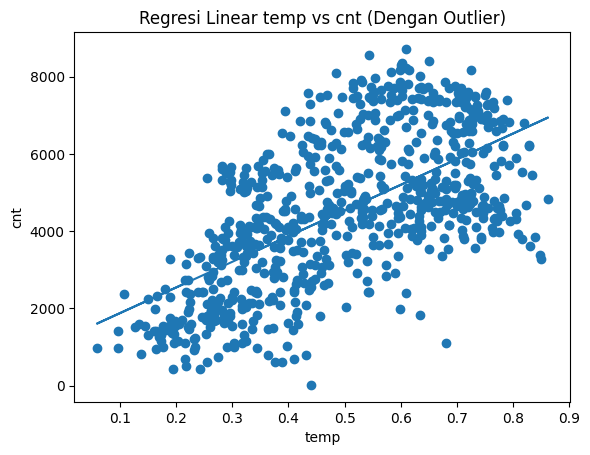

In [20]:
# hitung koefisien regresi
m, b = np.polyfit(df_clean['temp'], df_clean['cnt'], 1)

plt.figure()
plt.scatter(df_clean['temp'], df_clean['cnt'])

# garis regresi
plt.plot(df_clean['temp'], m*df_clean['temp'] + b)

plt.xlabel('temp')
plt.ylabel('cnt')
plt.title('Regresi Linear temp vs cnt (Dengan Outlier)')
plt.show()

# cek tipe data

In [21]:
# cek tipe data semua kolom
print(df.dtypes)

# cek tipe data khusus variabel X dan Y
print("\nTipe data temp:", df['temp'].dtype)
print("Tipe data cnt:", df['cnt'].dtype)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Tipe data temp: float64
Tipe data cnt: int64


# statistik deskriptis

In [22]:
df_no_outlier[['temp','cnt']].describe()
print("Median:")
print(df_no_outlier[['temp','cnt']].median())

print("\nVarians:")
print(df_no_outlier[['temp','cnt']].var())

print("\nStandar Deviasi:")
print(df_no_outlier[['temp','cnt']].std())

Median:
temp       0.498333
cnt     4548.000000
dtype: float64

Varians:
temp    3.350767e-02
cnt     3.752788e+06
dtype: float64

Standar Deviasi:
temp       0.183051
cnt     1937.211452
dtype: float64


## Analisis Korelasi

In [23]:
from scipy.stats import pearsonr

r, p_value = pearsonr(df_no_outlier['temp'], df_no_outlier['cnt'])

print("Koefisien Korelasi Pearson (r):", r)
print("P-value:", p_value)


Koefisien Korelasi Pearson (r): 0.6274940090334922
P-value: 2.8106223975893466e-81
